#Zomato Dataset Analysis


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhanupratapbiswas/zomato")

print("Path to dataset files:", path)

100%|██████████| 5.28M/5.28M [00:01<00:00, 3.98MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/bhanupratapbiswas/zomato/versions/1


In [ ]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(file)

zomato.csv


Understanding The Dataset

In [ ]:
import pandas as pd

df = pd.read_csv(path + "/zomato.csv")

df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [ ]:
df.columns


Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [ ]:
df.shape


(56252, 13)

In [ ]:
df.duplicated().sum()

np.int64(15703)

In [ ]:
df.isnull().sum()

,0
address,17
name,16
online_order,19
book_table,58
rate,7838
votes,78
phone,1296
location,126
rest_type,338
dish_liked,28225


In [ ]:
df['rate'].head(20)

,rate
0,4.1/5
1,4.1/5
2,3.8/5
3,3.7/5
4,3.8/5
5,3.8/5
6,3.6/5
7,4.6/5
8,4.0/5
9,\nTop floor


In [ ]:
df['approx_cost(for two people)'].head(20)

,approx_cost(for two people)
0,800
1,800
2,800
3,300
4,600
5,600
6,800
7,600
8,700
9,it turned out worse than the garlic bread. Th...


In [ ]:
df['approx_cost(for two people)'].sample(20)

,approx_cost(for two people)
31214,\ngrilled salmon
22316,200
39169,500
10786,200
4647,350
22976,"""""RATED\n Went to try the Amritsari Kulcha w..."
24074,400
30468,500
6290,650
4629,600


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

Data Cleaning

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(40549, 13)

In [ ]:
df = df.dropna(subset=['rate', 'cuisines', 'location'])

In [ ]:
df.isnull().sum()

,0
address,1
name,0
online_order,2
book_table,2
rate,0
votes,2
phone,565
location,0
rest_type,115
dish_liked,14040


In [ ]:
df['rate'] = df['rate'].astype(str)

In [18]:
df['rate'] = df['rate'].str.extract(r'(\d+\.\d+)')

In [19]:
df['rate'] = pd.to_numeric(df['rate'])

In [20]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)

In [21]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.extract(r'(\d+)')

In [22]:
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

In [23]:
df = df.dropna(subset=['rate', 'approx_cost(for two people)'])

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31162 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   address                      31162 non-null  object 
 1   name                         31162 non-null  object 
 2   online_order                 31162 non-null  object 
 3   book_table                   31162 non-null  object 
 4   rate                         31162 non-null  float64
 5   votes                        31162 non-null  object 
 6   phone                        30759 non-null  object 
 7   location                     31162 non-null  object 
 8   rest_type                    31051 non-null  object 
 9   dish_liked                   18529 non-null  object 
 10  cuisines                     31162 non-null  object 
 11  approx_cost(for two people)  31162 non-null  float64
 12  listed_in(type)              28442 non-null  object 
dtypes: float64(2), object

In [25]:
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

Starting Analysis
1.Average Rating

In [26]:
df['rate'].mean()

np.float64(3.713311084012579)

2.Rating Distribution

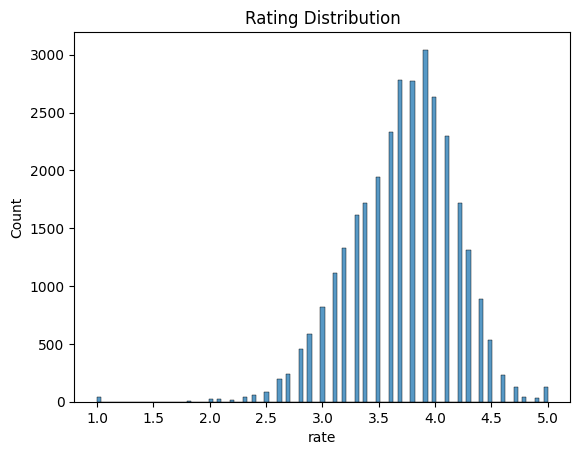

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['rate'])

plt.title("Rating Distribution")
plt.show()

3.Top Locations

In [28]:
location_count = df['location'].value_counts()

location_count.head(10)

,count
location,
BTM,2434
Koramangala 5th Block,1587
HSR,1553
Indiranagar,1544
Whitefield,1475
Marathahalli,1346
JP Nagar,1216
Jayanagar,1185
Bellandur,942


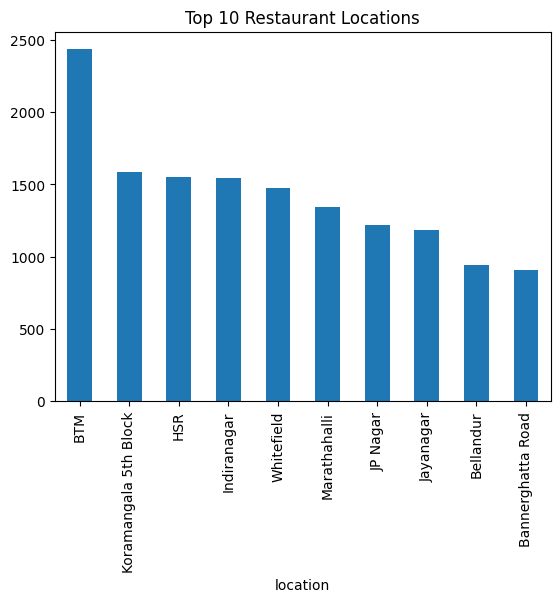

In [30]:
location_count.head(10).plot(kind='bar')

plt.title("Top 10 Restaurant Locations")
plt.show()

Cuisine Vs Rating

In [31]:
cuisine_rating = df.groupby('cuisines')['rate'].mean()

cuisine_rating.sort_values(ascending=False).head(10)

,rate
cuisines,
"""""RATED\n Well after long drive to city of Bengaluru from Hyderabad... we stayed at MG road. Clock ticked 1 pm and was damn hungry. Well then zomato came to help me along with my cousin who stays in Bengaluru.\n\nWent to this restaurant. Which is of Andhra cuisine. Well ambience wise is normal don't expect amazing theme. Courteous staff. Coming to food we ordered Thali and well well we enjoyed the meal and had a amazing time. Should try out here.\n\nAmazing place and pocket friendly.\n\nFood - 5\nAmbience- 3.5\nStaff - 4"""")",5.0
"""""RATED\n Food was nice I tasted prawns it was very tasty ...\nAnd Anjal also it was nice...its best for family people can njoy and have the food... It's nice ?"""")",5.0
"we had to cancel that.\nSo i dint wanted my hubby birthday to end like that so we moved out.\nFinal review - visit them when they are free."""")",5.0
"""""RATED\n Had their pizza at 2 am last night. Other reviews didn't make it look appealing but I didn't have too many other options. So I decided to try them anyway and I am very glad I did. I ordered the hot chicken pizza and it was really good for the price. Well done guys! Keep it up."""")",5.0
"""""RATED\n We subscribed to the nutri-meal for a week. The meals were homely and in perfect portions. We neither felt too full nor felt wanting for more. The menu was different everyday - even the dal was different. I got to eat turai and pumpkin sabzi - which are the kind of veggies you don't find in any restaurant. The 7 day dinners were near perfect substitutes of home cooked dinners."""")",5.0
"""""RATED\n I am visiting this place for last 4 years.\nCan't stop praising them.\none of the best pizza and baguettes in town.\nSalad is great and the calm atmosphere is wonderful.\nBest thing which makes this place outstanding is their pizza.\n\nkeep up the good work."""")",5.0
"""""RATED\n I don't have many words for this except for beautiful classy and romantic place..It's newly opened compared with other outlets in this location.. visited on Thursday evening for a birthday celebrations. And the place did not disappoint us..catch the glimpse of the places in all the pics"""")",5.0
"""""RATED\n I went for this place for quick bite after long client meeting as client office was in UB city and this place I want to go for long time but due to time constraints in past I couldn't do it but this time I didn't missed it.\nPlace is calm and cool definitely for evening drinks price was also OK not so high and taste was also good and freshly cooked.\nMy colleague ordered fruit salad and the presentation of salad was really nice but the quantity was too less as compared with price. It may be due to presentation.\nRest everything was nice for this place."""")",5.0
they are nice. Not a fan of pancakes with peanut butter and banana but managed to have it here. The staff is polite too.'),5.0


Rating Distribution Graph

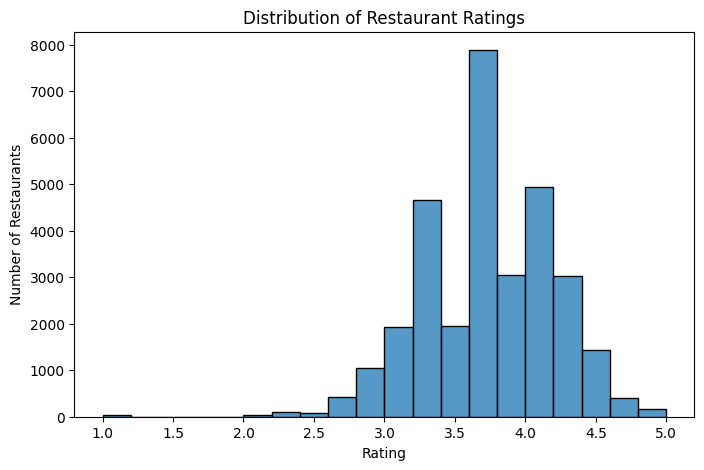

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(df['rate'], bins=20)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")

plt.show()

Top 10 Location Graph

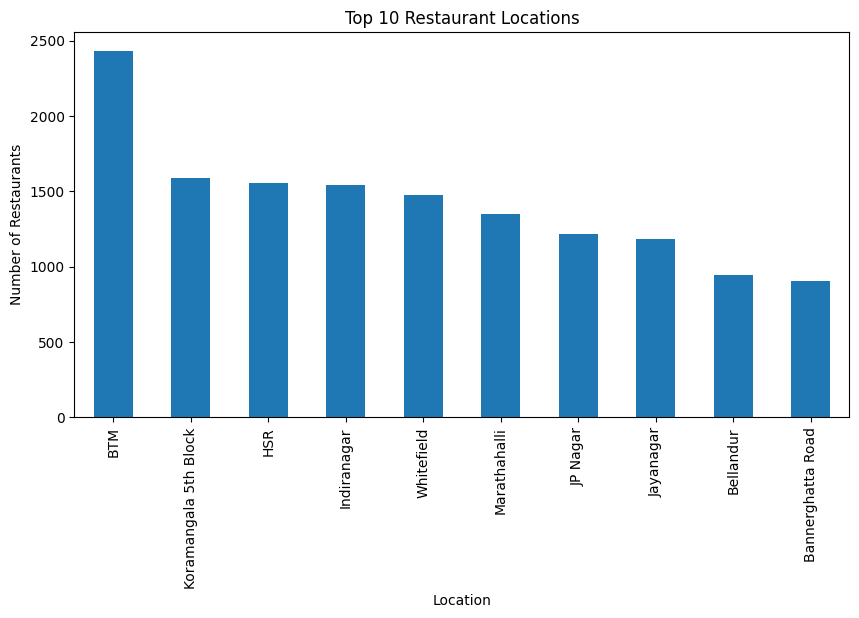

In [33]:
plt.figure(figsize=(10,5))

location_count.head(10).plot(kind='bar')

plt.title("Top 10 Restaurant Locations")
plt.xlabel("Location")
plt.ylabel("Number of Restaurants")

plt.show()

In [34]:
df['cuisines'].sample(20)

,cuisines
28705,"Tibetan, Chinese, Momos"
27061,Fast Food
8664,"South Indian, North Indian"
45171,"Chinese, North Indian, South Indian"
4971,Fast Food
43254,"Mithai, Street Food"
37745,"Biryani, Hyderabadi, North Indian"
43007,"North Indian, Chinese, Rolls"
26580,"Chinese, Fast Food"
7951,"Salad, Fast Food"


Price Vs Rating

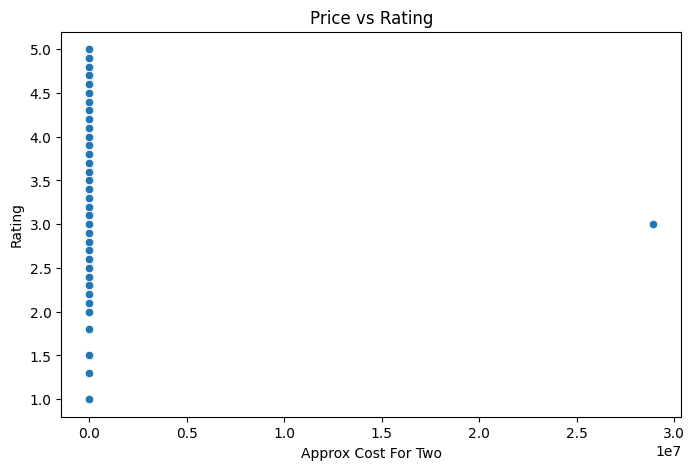

In [35]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='approx_cost(for two people)',
    y='rate',
    data=df
)

plt.title("Price vs Rating")
plt.xlabel("Approx Cost For Two")
plt.ylabel("Rating")

plt.show()

In [36]:
df['cuisines'].value_counts().head(10)

,count
cuisines,
North Indian,1582
"North Indian, Chinese",1448
South Indian,877
"Bakery, Desserts",477
Biryani,437
Cafe,413
"South Indian, North Indian, Chinese",411
Desserts,387
Fast Food,357


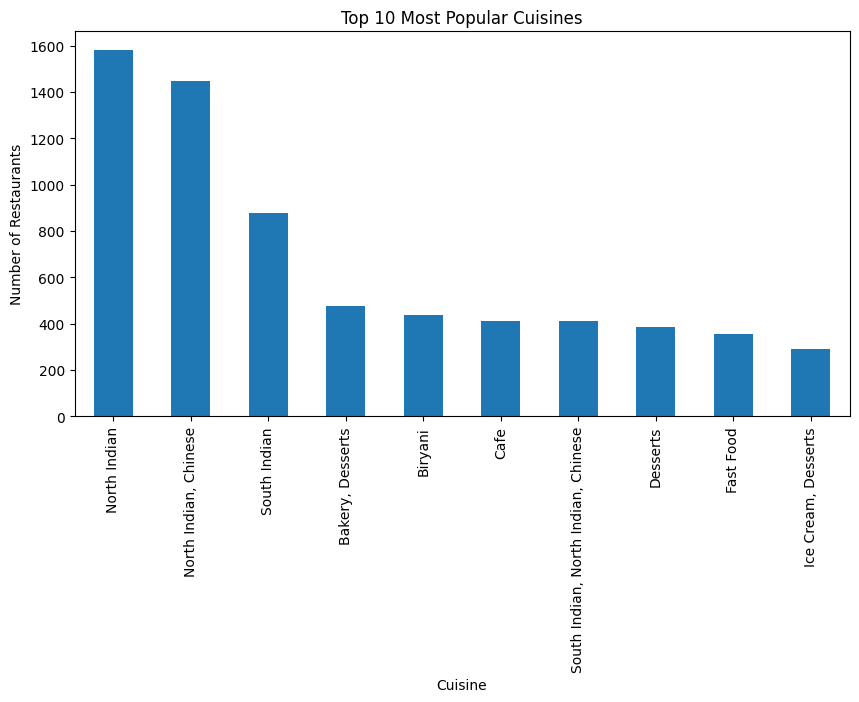

In [37]:
plt.figure(figsize=(10,5))

df['cuisines'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Most Popular Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")

plt.show()

Heatmap Analysis

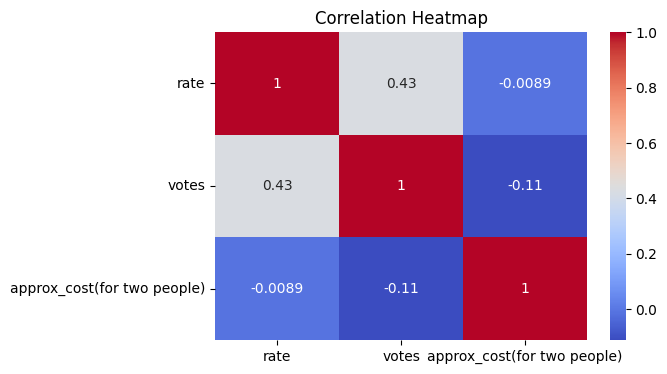

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df[['rate', 'votes', 'approx_cost(for two people)']]

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [39]:
pip install wordcloud

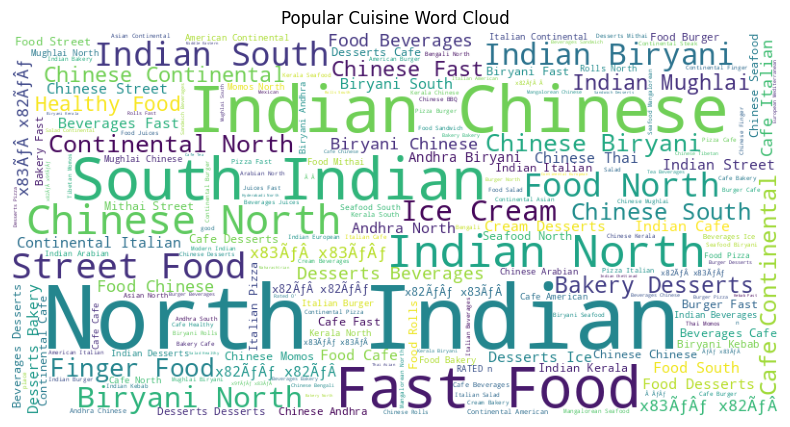

In [40]:
from wordcloud import WordCloud

text = " ".join(df['cuisines'].dropna())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Popular Cuisine Word Cloud")

plt.show()

In [41]:
df['cuisines'].value_counts().head(10)

,count
cuisines,
North Indian,1582
"North Indian, Chinese",1448
South Indian,877
"Bakery, Desserts",477
Biryani,437
Cafe,413
"South Indian, North Indian, Chinese",411
Desserts,387
Fast Food,357


In [42]:
numeric_df.corr()

,rate,votes,approx_cost(for two people)
rate,1.000000,0.430737,-0.008895
votes,0.430737,1.000000,-0.111688
approx_cost(for two people),-0.008895,-0.111688,1.000000
